<a href="https://colab.research.google.com/github/peremartra/Rearchitecting-LLMs/blob/main/CH07/CH07_NB01_From_Matrices_to_Quantization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width:100%; border:none; background:none;">
  <tr style="border:none;">
    <td style="border:none; vertical-align:middle; text-align:left; width: 120px;">
      <a href="https://hubs.la/Q040tvsK0"><img src="https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/Images/cover.png" width="100px" style="border-radius: 4px;"></a>
    </td>
    <td style="border:none; vertical-align:middle; text-align:left;">
      <p style="margin: 0; font-size: 14px;">
        Supplementary code for the <a href="https://hubs.la/Q040tvsK0">Rearchitecting LLMs</a> book by <a href="https://github.com/peremartra">Pere Martra</a>.<br>
        <br>
        Code repository: <a href="https://github.com/peremartra/Rearchitecting-LLMs">https://github.com/peremartra/Rearchitecting-LLMs</a>
      </p>
    </td>
  </tr>
</table>

#Rearchitecting LLMs
## Structural techniques for efficient models


### Chapter 7: Specialization Tuning.

[![LinkedIn](https://img.shields.io/badge/LinkedIn-0077B5?style=flat&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/pere-martra/) [![GitHub](https://img.shields.io/badge/GitHub-100000?style=flat&logo=github&logoColor=white)](https://github.com/peremartra) [![X](https://img.shields.io/badge/X-000000?style=flat&logo=x&logoColor=white)](https://x.com/PereMartra) [![Hugging Face](https://img.shields.io/badge/🤗%20Hugging%20Face-blue)](https://huggingface.co/oopere)

_____
Colab Environment: CPU

Models:
* HuggingFaceTB/SmolLM2-1.7B-Instruct
_____

This notebook explores the underlying mechanics of LoRA and DoRA and compares accuracy trade-offs across different quantization methods.

# Load & Show model

In [ ]:
from transformers import (
    AutoModelForCausalLM,
)

In [ ]:
MODEL_NAME= "HuggingFaceTB/SmolLM2-1.7B-Instruct"
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
)

## Inspecting the Base Architecture
By printing the model, we can inspect the Attention Modules inside the Transformer Blocks. Notice the dimensions of the linear layers like `q_proj` and `v_proj`—these massive matrices (2048x2048) are exactly what we want to avoid training fully to prevent high VRAM consumption and catastrophic forgetting.

In [ ]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 2048, padding_idx=2)
    (layers): ModuleList(
      (0-23): 24 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (v_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), ep

# 7.1.1 LoRA

In [ ]:
import torch

# d is the original dimension of the weight matrix we want to adapt.
# In SmolLM2-1.7B, q_proj projects from and to the model's hidden size.
d = 2048

# r is the LoRA rank — the bottleneck dimension of the two adapter matrices.
# A smaller r means fewer trainable parameters but less expressive power.
# Typical values range from 4 to 64; we use 8 here.
r = 8

# W represents the original frozen weight matrix (e.g. q_proj).
# In a real LoRA setup this matrix is never updated during training.
W = torch.randn(d, d)

# A and B are the two low-rank adapter matrices that LoRA trains.
# B is initialized to zeros at the start of training (as in the original paper),
# ensuring the model behaves exactly as the pretrained model before any learning.
A = torch.randn(d, r)
B = torch.zeros(r, d)

# ΔW is the learned update — what LoRA actually trains.
# Its dimensions match W exactly, so it can be added to W at inference time.
delta_W = A @ B

print(f"W dimensions:        {W.shape}")
print(f"ΔW dimensions:       {delta_W.shape}")
print()
params_W    = d * d
params_lora = d * r + r * d
reduction   = (1 - params_lora / params_W) * 100
print(f"Parameters in W:     {params_W:,}")
print(f"Parameters in A + B: {params_lora:,}")
print(f"Reduction:           {reduction:.1f}%")

# After training, B has learned non-zero values.
# We simulate a trained state here to demonstrate the effect on W.
# The small scale (0.01) reflects typical adapter magnitudes after fine-tuning.
B_trained = torch.randn(r, d) * 0.01
delta_W_trained = A @ B_trained

# At inference, ΔW is added to the frozen W to produce the adapted weights.
# The result has identical dimensions to W — the model's structure is unchanged.
W_adapted = W + delta_W_trained

print(f"\nW dimensions (unchanged):        {W_adapted.shape}")
print(f"Sample weights before adaptation: {W[0, :4]}")
print(f"Sample weights after adaptation:  {W_adapted[0, :4]}")


W dimensions:        torch.Size([2048, 2048])
ΔW dimensions:       torch.Size([2048, 2048])

Parameters in W:     4,194,304
Parameters in A + B: 32,768
Reduction:           99.2%

W dimensions (unchanged):        torch.Size([2048, 2048])
Sample weights before adaptation: tensor([-1.1684, -0.1492, -0.4845, -0.5751])
Sample weights after adaptation:  tensor([-1.1576, -0.1631, -0.4860, -0.6224])


## 7.1.2 The DoRA Evolution: Decoupling Magnitude and Direction
As we've seen, LoRA is incredibly efficient. However, it has a structural limitation: the update $\\Delta W$ couples both the magnitude (strength) and the direction (semantic meaning) of the weight vectors. In a full fine-tuning process, these two dimensions often move independently.

Weight-Decomposed Low-Rank Adaptation (DoRA) solves this by separating the original matrix into a magnitude vector ($m$) and a directional matrix ($V$). Let's simulate how DoRA applies the LoRA mechanics only to the directional component, allowing for finer adjustments and less degradation of the model's base capabilities.

In [ ]:
import torch

d = 2048
r = 4

# W0 is the pretrained weight matrix we want to adapt.
W0 = torch.randn(d, d)

# --- Decompose W0 into magnitude and direction ---
# The same separation we used in chapter 4 to measure cosine similarity:
# direction encodes meaning, magnitude encodes scale.
m = torch.norm(W0, dim=0, keepdim=True)          # shape: (1, d)
V = W0 / m                                        # shape: (d, d), unit-norm columns

# --- LoRA adapters learn the directional update ---
A = torch.randn(d, r)
B = torch.zeros(r, d)

# Simulate a trained state
B_trained = torch.randn(r, d) * 0.01

# Directional update: V shifted by ΔV = A @ B, then re-normalized
V_updated     = V + A @ B_trained
V_updated_norm = torch.norm(V_updated, dim=0, keepdim=True)

# The adapted weight: learned magnitude × updated unit direction
W_dora = m * (V_updated / V_updated_norm)         # shape: (d, d) — identical to W0

# --- Parameter comparison ---
params_lora   = d * r + r * d
params_dora_m = d                                 # the only addition over LoRA

print(f"W0 shape:                    {W0.shape}")
print(f"W_dora shape:                {W_dora.shape}")
print()
print(f"Parameters in A + B:         {params_lora:,}")
print(f"Additional magnitude params: {params_dora_m:,}")
print(f"Overhead over LoRA:          +{params_dora_m/params_lora*100:.2f}%")
print()
print(f"Sample W0[0, :4]:     {W0[0, :4]}")
print(f"Sample W_dora[0, :4]: {W_dora[0, :4]}")

W0 shape:                    torch.Size([2048, 2048])
W_dora shape:                torch.Size([2048, 2048])

Parameters in A + B:         16,384
Additional magnitude params: 2,048
Overhead over LoRA:          +12.50%

Sample W0[0, :4]:     tensor([-1.3111, -0.1597, -0.5458,  0.9187])
Sample W_dora[0, :4]: tensor([-1.0166, -0.3212, -0.2501,  1.6506])


# 7.2 Quantization

We've successfully reduced the *trainable* parameters using adapters like LoRA and DoRA. However, the base model itself still resides in our GPU memory at full 16-bit or 32-bit precision. Even if we aren't training those base weights, just holding them in memory can easily overwhelm consumer hardware.

This is where Quantization comes in. By mapping the frozen base weights to lower precision formats (like 8-bit or 4-bit integers), we can drastically cut down the memory footprint—up to a 75% reduction!

In the following cells, we will simulate different quantization strategies and visualize how they distort the original weight distribution.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def quantize_uniform(values, bits):          #1
    n_levels = 2**bits - 1
    v_min, v_max = values.min(), values.max()
    scale = (v_max - v_min) / n_levels
    quantized = np.round((values - v_min) / scale)
    return quantized, scale, v_min

def dequantize_uniform(quantized, scale, v_min):   #2
    return quantized * scale + v_min

def quantize_nf4(values):                    #3
    nf4_levels = np.array([
        -1.0, -0.6962, -0.5251, -0.3949, -0.2844, -0.1848,
        -0.0911, 0.0, 0.0796, 0.1609, 0.2461, 0.3379,
        0.4407, 0.5626, 0.7230, 1.0
    ])
    v_abs_max = np.abs(values).max()
    values_norm = values / v_abs_max          #4
    indices = np.argmin(
        np.abs(values_norm[:, None] - nf4_levels), axis=1
    )
    return nf4_levels[indices] * v_abs_max    #5

np.random.seed(42)
weights = np.random.normal(0, 1, 5000)       #6

q8, scale8, min8 = quantize_uniform(weights, bits=8)
recovered_8bit = dequantize_uniform(q8, scale8, min8)

q4, scale4, min4 = quantize_uniform(weights, bits=4)
recovered_4bit = dequantize_uniform(q4, scale4, min4)

recovered_nf4 = quantize_nf4(weights)        #7

print(f"Error cuadrático medio 8-bit:  {np.mean((weights - recovered_8bit)**2):.6f}")
print(f"Error cuadrático medio 4-bit:  {np.mean((weights - recovered_4bit)**2):.6f}")
print(f"Error cuadrático medio NF4:    {np.mean((weights - recovered_nf4)**2):.6f}")



Error cuadrático medio 8-bit:  0.000066
Error cuadrático medio 4-bit:  0.019200
Error cuadrático medio NF4:    0.012304


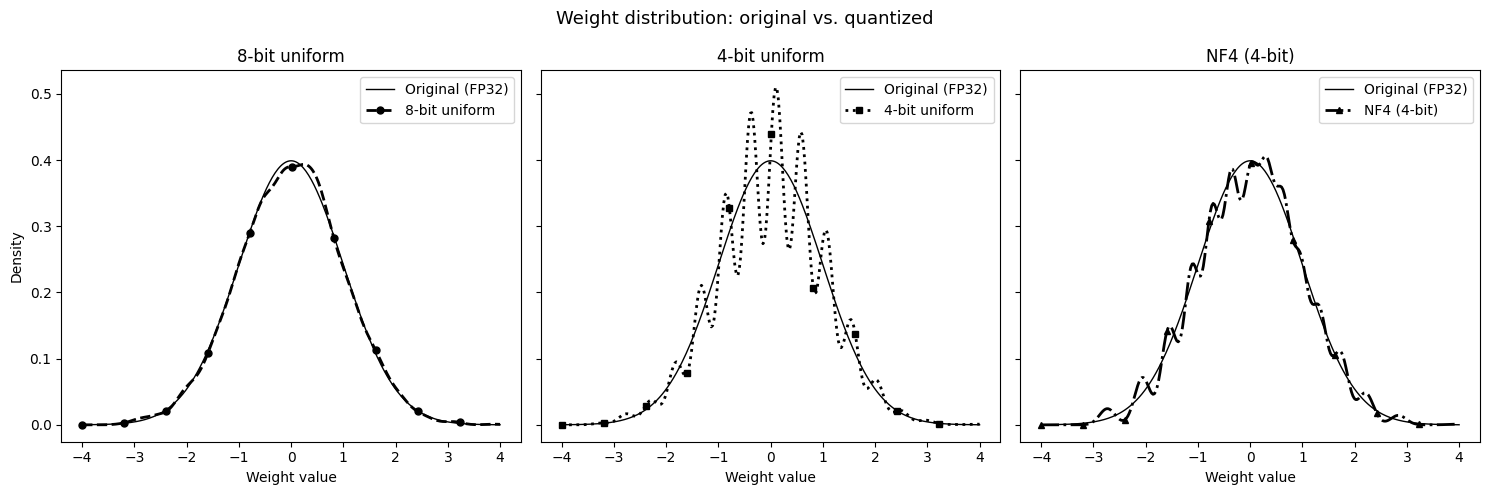

In [ ]:
x_range = np.linspace(-4, 4, 300)
sigma = 1.0

original_density = (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5*(x_range/sigma)**2)

def gaussian_kde(data, x_range, bandwidth=0.15):
    density = np.zeros_like(x_range)
    for xi in data:
        density += np.exp(-0.5 * ((x_range - xi) / bandwidth)**2)
    return density / (density.sum() * (x_range[1] - x_range[0]))

density_8bit = gaussian_kde(recovered_8bit, x_range)
density_4bit = gaussian_kde(recovered_4bit, x_range)
density_nf4  = gaussian_kde(recovered_nf4,  x_range)

comparisons = [
    (density_8bit, '8-bit uniform', 'k--', 'o'),
    (density_4bit, '4-bit uniform', 'k:',  's'),
    (density_nf4,  'NF4 (4-bit)',   'k-.', '^'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (density, label, style, marker) in zip(axes, comparisons):
    ax.plot(x_range, original_density, 'k-', linewidth=1.0, label='Original (FP32)')
    ax.plot(x_range, density, style, linewidth=2.0, label=label,
            marker=marker, markevery=30, markersize=5)
    ax.set_xlabel('Weight value')
    ax.set_title(label)
    ax.legend()

axes[0].set_ylabel('Density')

fig.suptitle('Weight distribution: original vs. quantized', fontsize=13)
plt.tight_layout()
plt.show()

## Summary

In this notebook, we translated the theoretical mechanics of model specialization into concrete operations. By running these simulations, you have practically verified:

* **The LoRA mechanic:** How decomposing updates into low-rank matrices ($\mathbf{A}$ and $\mathbf{B}$) slashes parameter counts.
* **The DoRA evolution:** How decoupling magnitude and direction alters the weight update behavior.
* **The Quantization impact:** How different formats (especially NF4) preserve or distort the model's weight distribution.

Now, return to the book. We are ready to combine these two isolated pieces—low-rank adapters and quantization—into a single, powerful pipeline to fine-tune a model on a custom dataset.